In [ ]:
!pip install formulaic

In [ ]:
!pip install linearmodels

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import  KFold
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import  RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import TransformerMixin, BaseEstimator
from linearmodels.iv import IV2SLS
from IPython.display import display
import warnings
import statsmodels.api as sm
from sklearn.neural_network import MLPRegressor
warnings.simplefilter('ignore')
np.random.seed(1234)

In [22]:
data = pd.read_stata('/home/onyxia/work/Who-When-and-Which-Program-Optimal-Allocation-of-Job-Search-Counseling/data/dataPrivatePublic.dta')

In [23]:
#data cleaning
from functions.data_cleaning import clean_data
df = clean_data(data)

## Can we recover causal results, using DML ?

In this part, we estimate the causal effect of actual participation (program take-up) using a Double Machine Learning (DML) framework. As the treatment was not randomized, we re-esimate the Local Average Treatment Effect for compliers under a DML framework. Basically, within the group of assigned persons, we will compare the employment outcome of the people that were treated and those that were not (the never-takers), controling for a series of variables observables (*U in the DAG graph presented in the previous part*). Then, we will compare the results with that of the paper, which used an IV strategy to compare the people that were assigned and treated to those that were not assigned and not treated.

We study this question for two different treatments (one associated to the intensive programm provided by the public service "CVE", the latter by the private sector "OPP").


### Programs participation

In [24]:
sample_cveopp = df.loc[df["SAMPLE_CVEOPP"] == 1]
table_pct = pd.crosstab(
    sample_cveopp["CVE"],
    sample_cveopp["acceptationCVE_6MOIS"],
    normalize="index"
) * 100

table_pct = table_pct.copy()
table_pct.index = ["Not assigned" if x == 0 else "Assigned" for x in table_pct.index]
table_pct.columns = ["Not treated" if x == 0 else "Treated" for x in table_pct.columns]

styled_table = (
    table_pct.style
    .format("{:.2f} %")
    .set_caption("Proportion of compliers, never-takers and always-takers (CVE)")
    .background_gradient(cmap="Blues", axis=None)
    .set_properties(
        subset=pd.IndexSlice[["Assigned"], ["Not treated"]],
        **{"background-color": "##f5b7b1"}
    )
)

styled_table

,Not treated,Treated
Not assigned,99.59 %,0.41 %
Assigned,69.22 %,30.78 %


Recall that, as regard to the public service intensive support, the tables shows that there are almost no always takers (0,41 % at horizon 6 months). However, the assignment do lead to non-compliance, 69 % of the assigned refusing to take the treatment.

In [25]:
table_opp = pd.crosstab(
    sample_cveopp["OPP"],
    sample_cveopp["acceptationOPP_6MOIS"],
    normalize="index"
) * 100

table_opp = table_opp.copy()
table_opp.index = ["Not assigned" if x == 0 else "Assigned" for x in table_opp.index]
table_opp.columns = ["Not treated" if x == 0 else "Treated" for x in table_opp.columns]

styled_table = (
    table_opp.style
    .format("{:.2f} %")
    .set_caption("Proportion of compliers, never-takers and always-takers (CVE)")
    .background_gradient(cmap="Blues", axis=None)
    .set_properties(
        subset=pd.IndexSlice[["Assigned"], ["Not treated"]],
        **{"background-color": "##f5b7b1"}
    )
)

styled_table

,Not treated,Treated
Not assigned,97.19 %,2.81 %
Assigned,57.40 %,42.60 %


As we can see, there is non-compliance with the private program too: some individuals assigned to the treatment group were not treated (57 % at horizon 6 months). The rate of never-takers is again very small.

### LATE results of the paper

First, let us retreive the result of the LATE found in the paper.

In [26]:
from functions.dml import fmt_coef_and_se
specs = [
    {
        "label": "Within 3 months", "y": "EMPLOI_3MOIS", "d_cve": "acceptationCVE_3MOIS",  "d_opp": "acceptationOPP_3MOIS", "w": "POIDS_PZ_3MOIS",
    },
    {
        "label": "Within 6 months", "y": "EMPLOI_6MOIS", "d_cve": "acceptationCVE_6MOIS","d_opp": "acceptationOPP_6MOIS", "w": "POIDS_PZ_6MOIS",
    },
    {
        "label": "Within 9 months", "y": "EMPLOI_9MOIS", "d_cve": "acceptationCVE_9MOIS", "d_opp": "acceptationOPP_9MOIS", "w": "POIDS_PZ_9MOIS",
    },
    {
        "label": "Within 12 months", "y": "EMPLOI_12MOIS", "d_cve": "acceptationCVE_12MOIS", "d_opp": "acceptationOPP_12MOIS", "w": "POIDS_PZ_12MOIS",
    },
]
X_limited = ["North", "IdF", "salaireG", "duree_listes_horsAR", "Insertion", "Q2", "agegr56", "exper0", "agegr4655", "French", "agegr3645", "Interim", "ce2", "Q3", "EndInterim", "salaireB", "primo", "agegr2635", "nivetude4", "tempcomp", "nivetude3", "salaireD", "EconLayoff", "PersLayoff", "salaireC", "Q1", "African", "salaireE"]

In [27]:
X_stata = [
    "nivetude1","nivetude3","nivetude4",
    "Cadre","Techn","EmployQ","EmployNQ","OuvrQ",
    "agegr2635","agegr3645","agegr4655","agegr56",
    "femme","marie",
    "onechild","twoormorechild",
    "French","African",
    "IdF","North",
    "ce1","ce2",
    "EconLayoff","PersLayoff","EndCDD","EndInterim",
    "exper0","exper1_5",
    "rsqstat2","rsqstat3",
    "tempcomp","dezus",
    "salaireB","salaireC","salaireD","salaireE","salaireG",
    "primo",
    "Insertion","Interim",
    "Q1","Q2","Q3"
]

iv_results_numeric = []

for spec in specs:

    cols = [
        spec["y"],
        spec["d_cve"],
        spec["d_opp"],
        "CVE",
        "OPP",
        spec["w"]
    ] + X_stata

    temp = df.loc[df["SAMPLE_CVEOPP"] == 1, cols].copy()

    for c in cols:
        temp[c] = pd.to_numeric(temp[c], errors="coerce")

    temp = temp.dropna()

    w_all = temp[spec["w"]]
    temp_valid = temp.loc[w_all > 0].copy()

    y = temp_valid[spec["y"]]
    d_cve = temp_valid[spec["d_cve"]]
    d_opp = temp_valid[spec["d_opp"]]
    z = temp_valid[["CVE", "OPP"]]
    X = temp_valid[X_stata]
    w = temp_valid[spec["w"]]

    # First stage
    Z1 = pd.concat([z, X], axis=1)
    Z1 = sm.add_constant(Z1, has_constant="add")

    fs_cve = sm.WLS(d_cve, Z1, weights=w).fit()
    fs_opp = sm.WLS(d_opp, Z1, weights=w).fit()

    d_cve_hat = fs_cve.fittedvalues.rename(spec["d_cve"])
    d_opp_hat = fs_opp.fittedvalues.rename(spec["d_opp"])

    # Second stage
    X2 = pd.concat([d_cve_hat, d_opp_hat, X], axis=1)
    X2 = sm.add_constant(X2, has_constant="add")

    ss = sm.WLS(y, X2, weights=w).fit(cov_type="HC1")

    iv_results_numeric.append({
        "horizon": spec["label"],
        "months": int(spec["label"].split()[1]),   # works if label = "3 months", etc.
        "coef_CVE_iv": ss.params[spec["d_cve"]],
        "se_CVE_iv": ss.bse[spec["d_cve"]],
        "coef_OPP_iv": ss.params[spec["d_opp"]],
        "se_OPP_iv": ss.bse[spec["d_opp"]],
        "n_iv": len(temp_valid)
    })

iv_summary = pd.DataFrame(iv_results_numeric).sort_values("months")
display(iv_summary)

,horizon,months,coef_CVE_iv,se_CVE_iv,coef_OPP_iv,se_OPP_iv,n_iv
0,Within 3 months,3,0.104153,0.032074,0.016903,0.016607,40939
1,Within 6 months,6,0.090415,0.036951,0.037993,0.020916,37952
2,Within 9 months,9,0.104967,0.036218,0.053408,0.022854,35509
3,Within 12 months,12,0.068465,0.036884,0.051875,0.023893,33500


## Now what happens when we compare only the treated and non treated, taking only into account the people that were assigned to the treatment ?

**We are wondering wether we can retrive the causal impact of each program (CVE and OPP) on the employment spell of the unemployed without using the results of the RCT.**

Indeed, forget about the assignment Z and consider only the subsample of the people that were assigned to the treatment. Some took it, others didn't. Suppose we have no unobserved variables U (*as displayed in the DAG graph of the previous part*). Then, the conditional ignorability assumption should hold. That is, we have : 

$$
Y(0), Y(1) \perp\!\!\!\perp D \mid X
$$

with T the treatment (either CVE or OPP), Y(0) and Y(1) the potential employment output and X the variables that both affect T and Y (*see the DAG graph*)

That means, controlling on X, the treatment T should be as good as random. Thus, comparing the people treated and non treated whithin those that were assigned, we should retrieve the results of the LATE.


We consider here a partially linear regression model. That is : 
$$
Y = \beta D + g(X)+ \epsilon
$$
with g being an arbitrary function. The conditional ignorability assumption (that here holds if and only if there are no omitted variables U) ensures $E[\epsilon|D, X]=0$. 

Partialling out elimates the unknown function g(X) and enables to retrieve the causal coefficient $\beta$. Thus, we take the conditional expectation in the previous model and substract it to initial equation.

### I define a transformer that constructs the engineered features for controls

In the first part, we have seen that, within the assigned group, both treated and non treated groups differ with regard to certain variables : prior unemployment, being or not foreign-born, education level (for CVE) and being or not married, the number of children, prior unemployment among others (for OPP). Thus, we build engineered features for control (adding other variables for precisions) to be injected in the DML framework.

In [36]:
from functions.dml import dml_single_treatment
from functions.dml import summary_single_treatment
from functions.dml import run_dml_grid
from functions.dml import select_best_learners 
from functions.dml import make_transformer

In [ ]:
X_engineered = [
    "North", "femme", "IdF", "salaireG", "Insertion", "Q2",
     "exper", "French", "age", "Interim", "ce2", "Q3", "EndInterim", "salaireB", "primo", "nivetude4",
    "tempcomp", "nivetude3", "salaireD", "EconLayoff", "PersLayoff",
    "salaireC", "Q1", "African", "salaireE", "duree_listes_horsAR", "marie", "nenf", "ce1",
]
sample_cveopp["exper"] = pd.to_numeric(sample_cveopp["exper"], errors="coerce")
sample_cveopp[X_engineered]

In [30]:
transformer = make_transformer(array=False)
transformer.fit_transform(sample_cveopp[X_engineered]).describe()

,"poly(age, degree=3, raw=True)[0]","poly(age, degree=3, raw=True)[1]","poly(age, degree=3, raw=True)[2]","poly(exper, degree=3, raw=True)[0]","poly(exper, degree=3, raw=True)[1]","poly(exper, degree=3, raw=True)[2]","poly(duree_listes_horsAR, degree=3, raw=True)[0]","poly(duree_listes_horsAR, degree=3, raw=True)[1]","poly(duree_listes_horsAR, degree=3, raw=True)[2]","poly(nenf, degree=2, raw=True)[0]",...,primo,Insertion,age:exper,femme:nenf,femme:exper,duree_listes_horsAR:exper,French:IdF,African:IdF,nivetude3:exper,nivetude4:exper
count,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000,4.397700e+04,43977.000000,...,43977.000000,43977.000000,43977.000000,43977.000000,43977.00000,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000
mean,36.714942,1458.313641,3164.318917,6.981672,111.910521,2497.422766,224.029373,64823.277344,2.057602e+07,0.902244,...,0.620529,0.276804,306.560998,0.484458,3.26357,1588.794993,0.635946,0.106715,2.222548,1.627578
std,10.503770,815.302898,19624.858003,7.947843,231.196534,7319.914763,120.972954,51300.066406,1.957052e+07,1.247945,...,0.485261,0.447424,416.496169,0.984388,6.24282,2229.955216,0.481169,0.308754,5.770111,5.206886
min,17.000000,289.000000,-32768.000000,0.000000,0.000000,0.000000,-87.400002,0.000000,-6.676277e+05,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,-1591.199974,0.000000,0.000000,0.000000,0.000000
25%,28.000000,784.000000,-14883.000000,1.000000,1.000000,1.000000,116.000000,13456.000000,1.560896e+06,0.000000,...,0.000000,0.000000,42.000000,0.000000,0.00000,167.999992,0.000000,0.000000,0.000000,0.000000
50%,35.000000,1225.000000,9261.000000,4.000000,16.000000,64.000000,237.000000,56169.000000,1.331205e+07,0.000000,...,1.000000,0.000000,135.000000,0.000000,0.00000,714.000000,1.000000,0.000000,0.000000,0.000000
75%,45.000000,2025.000000,19648.000000,10.000000,100.000000,1000.000000,353.000000,124609.000000,4.398698e+07,2.000000,...,1.000000,1.000000,396.000000,1.000000,4.00000,2072.000000,1.000000,0.000000,1.000000,0.000000
max,65.000000,4225.000000,31800.000000,42.000000,1764.000000,74088.000000,365.000000,133225.000000,4.862712e+07,9.000000,...,1.000000,1.000000,2480.000000,9.000000,42.00000,14965.000000,1.000000,1.000000,42.000000,42.000000


### Estimating the DML for the CVE treatment

We first estimate **nuisance parameters** $ E[Y|X] \text{ and } E[D|X]$ using machine learning methods and cross-fitting. To do so, we train various models : *Double lasso, logistic regression, random forests, boosting and neural networks*. We select in both cases the best model by minimising the RMSE on the test sets. Then, we estimate $\beta$ by using the partialling out methodology.

In this part we detail the procedure for the variable CVE at horizon 6 months. In the next part, we will simply display the overall results for both CVE and OPP. 

In [31]:
cve_dlm = sample_cveopp[sample_cveopp["CVE"] == 1].copy()
y = cve_dlm["EMPLOI_6MOIS"].values
D = cve_dlm['acceptationCVE_6MOIS'].values
X = cve_dlm[X_engineered]
weights = cve_dlm["POIDS_PZ_6MOIS"].values


In [32]:
#We define learners for both variables of interest in this first stage
cv = KFold(n_splits=5, shuffle=True, random_state=123)
learners_d = {

    "Logit": make_pipeline(transformer, StandardScaler(), LogisticRegressionCV(cv=cv, penalty='l2', solver='liblinear')), "RF": make_pipeline(transformer, RandomForestClassifier(n_estimators=100, min_samples_leaf=10, ccp_alpha=.001)), "Tree": make_pipeline(transformer, DecisionTreeClassifier(min_samples_leaf=10, ccp_alpha=.001)),  "GBF": make_pipeline(transformer, GradientBoostingClassifier(max_depth=2, n_iter_no_change=5)),  "MLP": make_pipeline(StandardScaler(),
                       MLPRegressor(hidden_layer_sizes=(50, 50, 50, 50),
                                    activation='relu',
                                    solver='adam',
                                    alpha=0.0001,
                                    batch_size=200,
                                    learning_rate='constant',
                                    learning_rate_init=0.001,
                                    max_iter=200,
                                    shuffle=True,
                                    random_state=None,
                                    tol=1e-4,
                                    verbose=False,
                                    warm_start=False,
                                    momentum=0.9,
                                    nesterovs_momentum=True,
                                    early_stopping=True,
                                    validation_fraction=0.2,
                                    beta_1=0.9,
                                    beta_2=0.999,
                                    epsilon=1e-08,
                                    n_iter_no_change=10)
                       )
}
learners_y = {
    "Logit": make_pipeline(transformer, StandardScaler(), LogisticRegressionCV(cv=cv, penalty='l2', solver='liblinear')),

    "RF":  make_pipeline(transformer, RandomForestClassifier(n_estimators=100, min_samples_leaf=10, ccp_alpha=.001)),

    "Tree": make_pipeline(transformer, DecisionTreeClassifier(min_samples_leaf=10, ccp_alpha=.001)),

    "GBF": make_pipeline(transformer, GradientBoostingClassifier(max_depth=2, n_iter_no_change=5)),

    "MLP": make_pipeline(StandardScaler(),
                       MLPRegressor(hidden_layer_sizes=(50, 50, 50, 50),
                                    activation='relu',
                                    solver='adam',
                                    alpha=0.0001,
                                    batch_size=200,
                                    learning_rate='constant',
                                    learning_rate_init=0.001,
                                    max_iter=200,
                                    shuffle=True,
                                    random_state=None,
                                    tol=1e-4,
                                    verbose=False,
                                    warm_start=False,
                                    momentum=0.9,
                                    nesterovs_momentum=True,
                                    early_stopping=True,
                                    validation_fraction=0.2,
                                    beta_1=0.9,
                                    beta_2=0.999,
                                    epsilon=1e-08,
                                    n_iter_no_change=10)
                       )
}

We estimate all combinations of learners for $E[Y|X] \text{ and } E[D|X]$ and compute goodness of fit.

In [ ]:
#All learners 
results_EMPLOI_6MOIS, models = run_dml_grid(
    X=X,
    y=y,
    D=D,
    w=weights,
    learners_y=learners_y,
    learners_d=learners_d
)

print("\nGoodness of fit and DML results for all combinations:\n") 

print(
    results_EMPLOI_6MOIS[
        [
            "learner_y",
            "learner_d",
            "treatment",
            "rmse y",
            "rmse D",
            "estimate",
            "stderr"
        ]
    ].to_string(index=False)
)


Goodness of fit and DML results for all combinations:

learner_y learner_d treatment   rmse y   rmse D  estimate   stderr
      GBF        RF   treated 0.314121 0.201875  0.059839 0.009719
      GBF       GBF   treated 0.314265 0.201006  0.059840 0.009753
      GBF      Tree   treated 0.314319 0.201876  0.059524 0.009720
      GBF       MLP   treated 0.314494 0.203319  0.057559 0.009682
      GBF     Logit   treated 0.314609 0.357588  0.058696 0.009767
    Logit       GBF   treated 0.318072 0.201073  0.059972 0.009905
    Logit      Tree   treated 0.318072 0.201876  0.059629 0.009871
    Logit        RF   treated 0.318072 0.201876  0.059621 0.009871
    Logit       MLP   treated 0.318072 0.203776  0.062640 0.009778
    Logit     Logit   treated 0.318072 0.357588  0.059310 0.009900
       RF      Tree   treated 0.320517 0.201876  0.062564 0.010021
       RF     Logit   treated 0.320675 0.357588  0.059711 0.010061
       RF       GBF   treated 0.320697 0.200973  0.062326 0.010068
      

We then select the best one for each variable.

In [ ]:
best_learner_y, best_learner_d = select_best_learners(results_EMPLOI_6MOIS)

In [40]:
dml_best = dml_single_treatment(
    X=X,
    D=D,
    y=y,
    w=weights,
    modely=learners_y[best_learner_y_name],
    modeld=learners_d[best_learner_d_name],
    nfolds=5,
    classifier_y=True,
    classifier_d=True,
    progress=True
)

(
    point, stderr, yhat, Dhat, resy, resD, epsilon, ols_mod
) = dml_best

print("Effet DML estimé :", point)
print("Erreur standard :", stderr)
print(ols_mod.summary())

DML steps: 100%|██████████| 4/4 [00:02<00:00,  1.85it/s]

Effet DML estimé : 0.04867389825932602
Erreur standard : 0.012448823197651088
                            WLS Regression Results                            
Dep. Variable:                   resy   R-squared:                       0.004
Model:                            WLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     15.29
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           9.41e-05
Time:                        17:25:59   Log-Likelihood:                   -inf
No. Observations:                3385   AIC:                               inf
Df Residuals:                    3383   BIC:                               inf
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

Now, we follow the same procedure for the variables *EMPLOI_3MOIS*, *EMPLOI_9MOIS* and *EMPLOI_12MOIS* to get the evolution of the coefficient. We do the same with OPP and compare with the IV results.

In [46]:
opp_dlm = sample_cveopp[sample_cveopp["OPP"] == 1].copy()
y = opp_dlm["EMPLOI_12MOIS"].values
D = opp_dlm['acceptationOPP_12MOIS'].values
X = opp_dlm[X_engineered]
weights = opp_dlm["POIDS_PZ_12MOIS"].values

results_EMPLOI_12MOIS, models = run_dml_grid(
    X=X,
    y=y,
    D=D,
    w=weights,
    learners_y=learners_y,
    learners_d=learners_d
)

results_EMPLOI_12MOIS.to_csv('/home/onyxia/work/Who-When-and-Which-Program-Optimal-Allocation-of-Job-Search-Counseling/data/learners_DML_EMPLOI12MOIS_opp.csv', index=False) #on enregistre la base

Running combination: Logit / Logit


KeyboardInterrupt: 

In [24]:
# =========================================
# 1) Define the specifications
# =========================================
specs = [
    {
        "label": "3 months",
        "results_file": "/home/onyxia/work/Who-When-and-Which-Program-Optimal-Allocation-of-Job-Search-Counseling/data/learners_DML_EMPLOI3MOIS.csv",
        "y_var": "EMPLOI_3MOIS",
        "d1_var": "acceptationCVE_3MOIS",
        "d2_var": "acceptationOPP_3MOIS",
    },
    {
        "label": "6 months",
        "results_file": "/home/onyxia/work/Who-When-and-Which-Program-Optimal-Allocation-of-Job-Search-Counseling/data/learners_DML_EMPLOI6MOIS.csv",
        "y_var": "EMPLOI_6MOIS",
        "d1_var": "acceptationCVE_6MOIS",
        "d2_var": "acceptationOPP_6MOIS",
    },
    {
        "label": "9 months",
        "results_file": "/home/onyxia/work/Who-When-and-Which-Program-Optimal-Allocation-of-Job-Search-Counseling/data/learners_DML_EMPLOI9MOIS.csv",
        "y_var": "EMPLOI_9MOIS",
        "d1_var": "acceptationCVE_9MOIS",
        "d2_var": "acceptationOPP_9MOIS",
    },
    {
        "label": "12 months",
        "results_file": "/home/onyxia/work/Who-When-and-Which-Program-Optimal-Allocation-of-Job-Search-Counseling/data/learners_DML_EMPLOI12MOIS.csv",
        "y_var": "EMPLOI_12MOIS",
        "d1_var": "acceptationCVE_12MOIS",
        "d2_var": "acceptationOPP_12MOIS",
    },
]

# =========================================
# 2) Store all results here
# =========================================
all_results = []
all_final_tables = {}

# =========================================
# 3) Loop over all horizons
# =========================================
for spec in specs:
    print(f"\n=== Running DML for {spec['label']} ===\n")

    # Load the table of learner performances
    results_dml = pd.read_csv(spec["results_file"])

    # Select best learners
    best_learner_y, best_learner_d1, best_learner_d2 = select_best_learners(results_dml)

    print("Selected learners:")
    print(" best_learner_y  =", best_learner_y)
    print(" best_learner_d1 =", best_learner_d1)
    print(" best_learner_d2 =", best_learner_d2)

    # Build variables for this horizon
    y = sample_cveopp[spec["y_var"]]
    D1 = sample_cveopp[spec["d1_var"]]
    D2 = sample_cveopp[spec["d2_var"]]

    # Optional: restrict to complete cases
    temp = pd.concat([X, y, D1, D2], axis=1).dropna()
    X_use = temp[X.columns]
    y_use = temp[spec["y_var"]]
    D1_use = temp[spec["d1_var"]]
    D2_use = temp[spec["d2_var"]]

    # Run DML with the selected learners
    dml_best = dml_two_treatments(
        X=X_use,
        D1=D1_use,
        D2=D2_use,
        y=y_use,
        modely=learners_y[best_learner_y],
        modeld1=learners_d[best_learner_d1],
        modeld2=learners_d[best_learner_d2],
        nfolds=5,
        classifier_y=True,
        classifier_d1=True,
        classifier_d2=True,
        cluster=False,
        progress=True
    )

    (
        point1, point2, stderr1, stderr2,
        yhat, D1hat, D2hat,
        resy, resD1, resD2,
        epsilon
    ) = dml_best

    # Detailed final table for this horizon
    final_table = make_dml_final_table(
        point1, point2, stderr1, stderr2,
        resy, resD1, resD2, epsilon,
        name1="CVE_treated",
        name2="OPP_treated",
        learner_y=best_learner_y,
        learner_d1=best_learner_d1,
        learner_d2=best_learner_d2,
        n=len(y_use)
    )

    all_final_tables[spec["label"]] = final_table

    print("\nFinal DML results")
    print(final_table.to_string(index=False))

    # Save compact summary row
    all_results.append({
        "horizon": spec["label"],
        "outcome": spec["y_var"],
        "best_learner_y": best_learner_y,
        "best_learner_d1": best_learner_d1,
        "best_learner_d2": best_learner_d2,
        "coef_CVE": point1,
        "se_CVE": stderr1,
        "coef_OPP": point2,
        "se_OPP": stderr2,
        "n": len(y_use),
    })

# =========================================
# 4) Final summary database
# =========================================
summary_table = pd.DataFrame(all_results)

print("\n=== Summary table across all horizons ===\n")
display(summary_table)


=== Running DML for 3 months ===

Best learner for Y:
learner_y   rmse y
      GBF 0.241516
     Tree 0.245655
    Logit 0.247076
       RF 0.247817
      MLP 0.250243

Best learner for D1:
learner_d  rmse D1
      GBF 0.156158
     Tree 0.156307
       RF 0.156307
      MLP 0.157900
    Logit 0.303760

Best learner for D2:
learner_d  rmse D2
      GBF 0.461472
    Logit 0.462438
      MLP 0.466043
     Tree 0.468016
       RF 0.468785

Selected learners:
Y  = GBF
D1 = GBF
D2 = GBF
Selected learners:
 best_learner_y  = GBF
 best_learner_d1 = GBF
 best_learner_d2 = GBF


DML steps:   0%|          | 0/5 [00:00<?, ?it/s]

DML steps: 100%|██████████| 5/5 [00:23<00:00,  4.64s/it]



Final DML results
  treatment  estimate  std.error        z  p.value  ci.lower  ci.upper   rmse_y  rmse_d1  rmse_d2  rmse_final learner_y learner_d1 learner_d2     n
CVE_treated  0.041635   0.007439 5.597037      0.0  0.027055  0.056215 0.241717 0.156133 0.461446    0.241565       GBF        GBF        GBF 43977
OPP_treated  0.014072   0.002517 5.590739      0.0  0.009138  0.019005 0.241717 0.156133 0.461446    0.241565       GBF        GBF        GBF 43977

=== Running DML for 6 months ===

Best learner for Y:
learner_y   rmse y
      GBF 0.313108
    Logit 0.317424
     Tree 0.319182
       RF 0.319450
      MLP 0.321071

Best learner for D1:
learner_d  rmse D1
      GBF 0.163339
     Tree 0.163514
       RF 0.163514
      MLP 0.164964
    Logit 0.306316

Best learner for D2:
learner_d  rmse D2
      GBF 0.463499
    Logit 0.464799
      MLP 0.468207
     Tree 0.470242
       RF 0.470959

Selected learners:
Y  = GBF
D1 = GBF
D2 = GBF
Selected learners:
 best_learner_y  = GBF
 best_l

DML steps: 100%|██████████| 5/5 [00:18<00:00,  3.68s/it]


...

DML steps: 100%|██████████| 5/5 [00:15<00:00,  3.20s/it]



Final DML results
  treatment  estimate  std.error         z  p.value  ci.lower  ci.upper   rmse_y  rmse_d1  rmse_d2  rmse_final learner_y learner_d1 learner_d2     n
CVE_treated  0.120844   0.009781 12.355613      0.0  0.101674  0.140014 0.353002 0.173444  0.46414    0.351848       GBF        GBF        GBF 43977
OPP_treated  0.048876   0.003655 13.372846      0.0  0.041712  0.056040 0.353002 0.173444  0.46414    0.351848       GBF        GBF        GBF 43977

=== Running DML for 12 months ===

Best learner for Y:
learner_y   rmse y
      GBF 0.381369
    Logit 0.384556
       RF 0.387339
      MLP 0.388118
     Tree 0.388639

Best learner for D1:
learner_d  rmse D1
      GBF 0.178292
     Tree 0.178627
       RF 0.178627
      MLP 0.180080
    Logit 0.311959

Best learner for D2:
learner_d  rmse D2
      GBF 0.464433
    Logit 0.465731
      MLP 0.469080
     Tree 0.470856
       RF 0.471730

Selected learners:
Y  = GBF
D1 = GBF
D2 = GBF
Selected learners:
 best_learner_y  = GBF
 be

DML steps: 100%|██████████| 5/5 [00:16<00:00,  3.26s/it]


Final DML results
  treatment  estimate  std.error         z  p.value  ci.lower  ci.upper   rmse_y  rmse_d1  rmse_d2  rmse_final learner_y learner_d1 learner_d2     n
CVE_treated  0.119428   0.010288 11.607984      0.0  0.099263  0.139593 0.381387  0.17828 0.464465    0.380135       GBF        GBF        GBF 43977
OPP_treated  0.055659   0.003949 14.093977      0.0  0.047918  0.063399 0.381387  0.17828 0.464465    0.380135       GBF        GBF        GBF 43977

=== Summary table across all horizons ===



,horizon,outcome,best_learner_y,best_learner_d1,best_learner_d2,coef_CVE,se_CVE,coef_OPP,se_OPP,n
0,3 months,EMPLOI_3MOIS,GBF,GBF,GBF,0.041635,0.007439,0.014072,0.002517,43977
1,6 months,EMPLOI_6MOIS,GBF,GBF,GBF,0.089331,0.009205,0.039447,0.003245,43977
2,9 months,EMPLOI_9MOIS,GBF,GBF,GBF,0.120844,0.009781,0.048876,0.003655,43977
3,12 months,EMPLOI_12MOIS,GBF,GBF,GBF,0.119428,0.010288,0.055659,0.003949,43977


In [25]:
dml_summary = summary_table.copy()

dml_summary["months"] = dml_summary["horizon"].str.extract(r"(\d+)").astype(int)

dml_summary = dml_summary.rename(columns={
    "coef_CVE": "coef_CVE_dml",
    "se_CVE": "se_CVE_dml",
    "coef_OPP": "coef_OPP_dml",
    "se_OPP": "se_OPP_dml"
})

plot_df = pd.merge(
    dml_summary[["months", "coef_CVE_dml", "se_CVE_dml", "coef_OPP_dml", "se_OPP_dml"]],
    iv_summary[["months", "coef_CVE_iv", "se_CVE_iv", "coef_OPP_iv", "se_OPP_iv"]],
    on="months",
    how="inner"
).sort_values("months")

display(plot_df)

,months,coef_CVE_dml,se_CVE_dml,coef_OPP_dml,se_OPP_dml,coef_CVE_iv,se_CVE_iv,coef_OPP_iv,se_OPP_iv
0,3,0.041635,0.007439,0.014072,0.002517,0.104153,0.032074,0.016903,0.016607
1,6,0.089331,0.009205,0.039447,0.003245,0.090415,0.036951,0.037993,0.020916
2,9,0.120844,0.009781,0.048876,0.003655,0.104967,0.036218,0.053408,0.022854
3,12,0.119428,0.010288,0.055659,0.003949,0.068465,0.036884,0.051875,0.023893


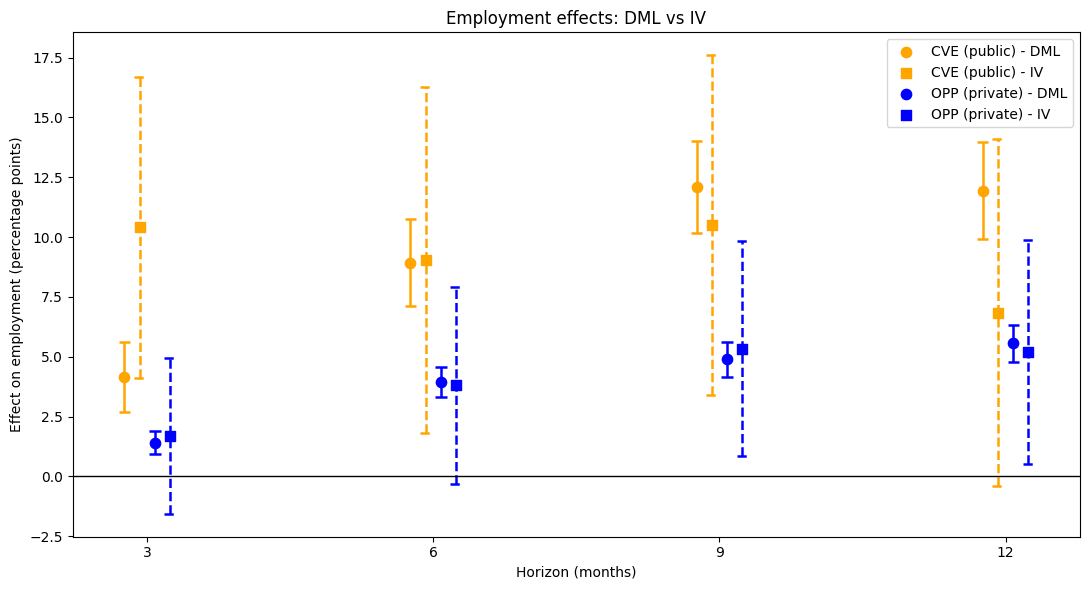

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# x positions
x = plot_df["months"].to_numpy()

# coefficients en points de pourcentage
cve_dml = 100 * plot_df["coef_CVE_dml"].to_numpy()
cve_dml_se = 100 * plot_df["se_CVE_dml"].to_numpy()

cve_iv = 100 * plot_df["coef_CVE_iv"].to_numpy()
cve_iv_se = 100 * plot_df["se_CVE_iv"].to_numpy()

opp_dml = 100 * plot_df["coef_OPP_dml"].to_numpy()
opp_dml_se = 100 * plot_df["se_OPP_dml"].to_numpy()

opp_iv = 100 * plot_df["coef_OPP_iv"].to_numpy()
opp_iv_se = 100 * plot_df["se_OPP_iv"].to_numpy()

# positions côte à côte
offset = 0.16
x_cve_dml = x - 1.5 * offset
x_cve_iv  = x - 0.5 * offset
x_opp_dml = x + 0.5 * offset
x_opp_iv  = x + 1.5 * offset

# style des IC
z = 1.96
cap_width = 0.06

fig, ax = plt.subplots(figsize=(11, 6))

def draw_errorbars(ax, xvals, yvals, ses, color, linestyle, marker, label):
    lower = yvals - z * ses
    upper = yvals + z * ses

    # ligne verticale
    ax.vlines(xvals, lower, upper, colors=color, linestyles=linestyle, linewidth=1.8)

    # petits caps horizontaux
    for xi, lo, up in zip(xvals, lower, upper):
        ax.hlines(lo, xi - cap_width, xi + cap_width, colors=color, linestyles=linestyle, linewidth=1.8)
        ax.hlines(up, xi - cap_width, xi + cap_width, colors=color, linestyles=linestyle, linewidth=1.8)

    # point estimate
    ax.scatter(xvals, yvals, color=color, marker=marker, s=55, label=label, zorder=3)

# CVE = orange
draw_errorbars(
    ax, x_cve_dml, cve_dml, cve_dml_se,
    color="orange", linestyle="solid", marker="o",
    label="CVE (public) - DML"
)

draw_errorbars(
    ax, x_cve_iv, cve_iv, cve_iv_se,
    color="orange", linestyle="dashed", marker="s",
    label="CVE (public) - IV"
)

# OPP = bleu
draw_errorbars(
    ax, x_opp_dml, opp_dml, opp_dml_se,
    color="blue", linestyle="solid", marker="o",
    label="OPP (private) - DML"
)

draw_errorbars(
    ax, x_opp_iv, opp_iv, opp_iv_se,
    color="blue", linestyle="dashed", marker="s",
    label="OPP (private) - IV"
)

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(x.astype(int))
ax.set_xlabel("Horizon (months)")
ax.set_ylabel("Effect on employment (percentage points)")
ax.set_title("Employment effects: DML vs IV")
ax.legend()
plt.tight_layout()
plt.show()